In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


# Instrument Distances with average over Styles

In [2]:
import os
import re
import pandas as pd
import arff
from collections import defaultdict
import numpy as np
from itertools import combinations

base_path = r"instrument_distances\mcadams_-1\average_absolute_distance"
instrument_pair_distances = defaultdict(list)

# Helper function to extract instrument name from distance column
def extract_instrument_name(col):
    match = re.match(r"Distance to instrument \d+ \((.*?)\), style \d+", col)
    return match.group(1) if match else None

# Loop through pitches
for i in range(20, 109):
    filename = f"{i}.arff"
    file_path = os.path.join(base_path, filename)

    with open(file_path, 'r') as f:
        data = arff.load(f)

    df = pd.DataFrame(data['data'], columns=[attr[0] for attr in data['attributes']])

    # Extract distance columns and map them to instrument names
    distance_cols = [col for col in df.columns if col.startswith("Distance to instrument")]
    col_to_instrument = {col: extract_instrument_name(col) for col in distance_cols}
    present_instruments = df['Instrument'].unique()

    # For each instrument pair, get distances between their styles
    for inst1, inst2 in combinations(sorted(present_instruments), 2):
        rows_inst1 = df[df['Instrument'] == inst1]
        rows_inst2 = df[df['Instrument'] == inst2]
        distances = []

        # For each style of inst1, look for distances to each style of inst2
        for _, row in rows_inst1.iterrows():
            for col in distance_cols:
                target_inst = col_to_instrument[col]
                if target_inst == inst2:
                    val = row[col]
                    if val is not None and not pd.isna(val):
                        distances.append(val)

        # Add all found distances for this pitch to the pair
        if distances:
            instrument_pair_distances[(inst1, inst2)].extend(distances)

# Compute final mean distances
mean_distances = {
    pair: np.mean(dists)
    for pair, dists in instrument_pair_distances.items()
}

# Convert to DataFrame
mean_df = pd.DataFrame([
    {'Instrument 1': pair[0], 'Instrument 2': pair[1], 'Mean Distance': mean}
    for pair, mean in mean_distances.items()
])

pivot_df = mean_df.pivot(index='Instrument 1', columns='Instrument 2', values='Mean Distance')

## Min-Max-Scaling

In [3]:
all_means = list(mean_distances.values())
min_mean = min(all_means)
max_mean = max(all_means)

scaled_mean_distances = {
    pair: (mean - min_mean) / (max_mean - min_mean)
    for pair, mean in mean_distances.items()
}

mean_scaled_df = pd.DataFrame([
    {'Instrument 1': pair[0], 'Instrument 2': pair[1], 'Scaled Mean Distance': scaled}
    for pair, scaled in scaled_mean_distances.items()
])
scaled_pivot_df = mean_scaled_df.pivot(index='Instrument 1', columns='Instrument 2', values='Scaled Mean Distance')

## Transform to complete distance matrix

In [4]:
symmetric_distances = []
instruments = set()

for (inst1, inst2), mean in scaled_mean_distances.items():
    symmetric_distances.append({'Instrument 1': inst1, 'Instrument 2': inst2, 'Mean Distance': mean})
    symmetric_distances.append({'Instrument 1': inst2, 'Instrument 2': inst1, 'Mean Distance': mean})
    instruments.update([inst1, inst2])

# Step 3: Add diagonal (self-distance = 0)
for inst in instruments:
    symmetric_distances.append({'Instrument 1': inst, 'Instrument 2': inst, 'Mean Distance': 0.0})

# Step 4: Convert to DataFrame
symmetric_df = pd.DataFrame(symmetric_distances)

# Step 5: Pivot to square symmetric matrix
distance_matrix = symmetric_df.pivot(index='Instrument 1', columns='Instrument 2', values='Mean Distance')

# Step 6: Ensure consistent instrument order
distance_matrix = distance_matrix.reindex(index=sorted(instruments), columns=sorted(instruments))

In [5]:
from IPython.display import display

pd.options.display.max_columns = None
display(distance_matrix)

Instrument 2,AcousticGuitar,Balalaika,Bandura,BanjoFramus,Banjolin,Bass,Bassoon,Bawu,Bouzouki,Cello,CeylonGuitar,Clarinet,Contrabassoon,Cumbus,DallapeAccordion,Dilruba,Domra,Drums,DungDkarTrumpet,EgyptianFiddle,ElectricBass,ElectricGuitar,ElectricPiano,Erhu,Flugelhorn,Flute,Fujara,Horn,JinghuOperaViolin,Kantele,Melodica,MorinKhuurViolin,Oboe,Organ,Oud,Panflute,Piano,Pinkillo,PivanaFlute,Saxophone,ScaleChangerHarmonium,Shakuhachi,Sitar,Tampura,Tanbur,Trombone,Trumpet,Tuba,TurkeySaz,Ukulele,Viola,Violin
Instrument 1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AcousticGuitar,0.000000,0.249905,0.298253,0.349239,0.246367,0.346028,0.277480,0.290096,0.357807,0.304378,0.622138,0.418849,0.299067,0.336231,0.797148,0.537062,0.283620,0.734878,0.288042,0.819297,0.244100,0.088642,0.286716,0.345036,0.392132,0.233607,0.457111,0.345143,0.525481,0.138004,0.540374,0.457868,0.345787,0.288197,0.324590,0.693140,0.240194,0.475153,0.284984,0.492500,0.760996,0.442755,0.432708,0.484920,0.332024,0.394662,0.360226,0.320505,0.464299,0.292986,0.314676,0.340573
Balalaika,0.249905,0.000000,0.252383,0.080406,0.043465,0.268994,0.302239,0.162560,0.115631,0.301536,0.422764,0.353572,0.216334,0.054712,0.489413,0.288964,0.046295,0.459112,0.175697,0.530692,0.029630,0.228732,0.112248,0.127505,0.172410,0.273597,0.314542,0.269960,0.170640,0.126385,0.196070,0.164669,0.200529,0.220512,0.105772,0.371158,0.277584,0.301560,0.307869,0.276795,0.483477,0.210635,0.159056,0.251791,0.046154,0.294389,0.243582,0.386364,0.190680,0.092338,0.304348,0.263251
Bandura,0.298253,0.252383,0.000000,0.425270,0.309433,0.336491,0.233581,0.254450,0.266820,0.283119,0.456136,0.181254,0.190179,0.320219,0.510680,0.300434,0.360992,0.665286,0.210561,0.653029,0.152332,0.291665,0.212573,0.225348,0.229134,0.216317,0.278717,0.185420,0.379976,0.138081,0.355527,0.303196,0.153194,0.261092,0.324111,0.515738,0.377024,0.158154,0.118205,0.272257,0.525604,0.306681,0.425227,0.309385,0.309364,0.259653,0.261251,0.289268,0.311937,0.476887,0.240466,0.240811
BanjoFramus,0.349239,0.080406,0.425270,0.000000,0.134120,0.282557,0.391468,0.317689,0.231948,0.407862,0.424663,0.516225,0.249272,0.035425,0.367447,0.371114,0.056381,0.447258,0.320577,0.456115,0.097514,0.301590,0.217287,0.322303,0.334580,0.501302,0.441006,0.383631,0.221916,0.292336,0.277871,0.262131,0.409354,0.354428,0.109740,0.364220,0.462795,0.581322,0.548585,0.357750,0.500539,0.347120,0.141617,0.207128,0.086211,0.368575,0.389208,0.449621,0.242680,0.052437,0.444565,0.429472
Banjolin,0.246367,0.043465,0.309433,0.134120,0.000000,0.241402,0.283214,0.129042,0.137607,0.244242,0.508960,0.327358,0.194429,0.028424,0.478742,0.259404,0.082496,0.466255,0.134468,0.557082,0.055165,0.183631,0.100436,0.122136,0.169247,0.243971,0.245209,0.251210,0.237405,0.142695,0.223428,0.153349,0.170001,0.167236,0.205943,0.310841,0.234887,0.278909,0.243942,0.247817,0.570611,0.212554,0.147179,0.262519,0.012587,0.262366,0.242164,0.365369,0.208246,0.103584,0.265338,0.231885
Bass,0.346028,0.268994,0.336491,0.282557,0.241402,0.000000,0.125877,0.067740,0.290980,0.206173,0.766943,0.115347,0.186273,0.248274,0.475636,0.204519,0.242369,0.910379,0.076113,0.541117,0.445884,0.281763,0.336974,0.139115,0.202458,0.036215,0.211655,0.153158,NaN,0.329187,0.270123,0.119270,0.054366,0.319172,0.278646,0.562712,0.413935,NaN,NaN,0.195039,0.397449,0.197219,0.264852,0.268608,0.282478,0.248449,0.159146,0.181413,0.204930,0.173160,0.142840,0.123601
Bassoon,0.277480,0.302239,0.233581,0.391468,0.283214,0.125877,0.000000,0.111977,0.321428,0.136182,0.700885,0.121387,0.047475,0.300241,0.486879,0.245106,0.365388,0.823253,0.072450,0.586807,0.310020,0.229193,0.231009,0.166839,0.197520,0.057520,0.215049,0.047113,0.323960,0.182261,0.279550,0.193292,0.105452,0.196100,0.359241,0.444502,0.329948,0.125094,0.009232,0.205922,0.478600,0.164378,0.328359,0.281901,0.284480,0.128414,0.163381,0.069666,0.210662,0.336514,0.098015,0.125511
Bawu,0.290096,0.162560,0.254450,0.317689,0.129042,0.067740,0.111977,0.000000,0.158069,0.103674,0.684

In [6]:
with pd.option_context('display.max_rows', None):
    print(mean_scaled_df) 

               Instrument 1           Instrument 2  Scaled Mean Distance
0                     Piano               Trombone              0.379753
1                     Piano                   Tuba              0.357914
2                  Trombone                   Tuba              0.172427
3             Contrabassoon                  Piano              0.302764
4             Contrabassoon               Trombone              0.107962
5             Contrabassoon                   Tuba              0.087480
6             Contrabassoon           ElectricBass              0.245735
7              ElectricBass                  Piano              0.313211
8              ElectricBass               Trombone              0.275870
9              ElectricBass                   Tuba              0.364308
10                     Bass          Contrabassoon              0.186273
11                     Bass           ElectricBass              0.445884
12                     Bass          ElectricPiano 

## Handling NA-values

If the range of the pitches of 2 instruments doesn't overlap this value is set to the maximum distance. In this case max dist=1.

In [7]:
instrument_pair_counts = defaultdict(int)

for i in range(20, 109):
    filename = f"{i}.arff"
    file_path = os.path.join(base_path, filename)

    with open(file_path, 'r') as f:
        data = arff.load(f)

    df = pd.DataFrame(data['data'], columns=[attr[0] for attr in data['attributes']])

    instruments_present = df['Instrument'].unique()

    for inst1, inst2 in combinations(sorted(instruments_present), 2):
        instrument_pair_counts[(inst1, inst2)] += 1

# Find all instruments
all_instruments = set()
for pair in instrument_pair_counts:
    all_instruments.update(pair)

# Create all possible instrument pairs
all_possible_pairs = set(combinations(sorted(all_instruments), 2))

# Identify missing pairs
missing_pairs = all_possible_pairs - set(instrument_pair_counts.keys())

# Show missing pairs (never appeared together on any pitch)
print(f"\nInstrument pairs that never co-occurred on any pitch ({len(missing_pairs)} pairs):\n")
for pair in sorted(missing_pairs):
    print(f"{pair[0]} - {pair[1]}")


Instrument pairs that never co-occurred on any pitch (19 pairs):

Bass - JinghuOperaViolin
Bass - Pinkillo
Bass - PivanaFlute
Bawu - Tampura
CeylonGuitar - JinghuOperaViolin
CeylonGuitar - Pinkillo
CeylonGuitar - PivanaFlute
Contrabassoon - JinghuOperaViolin
Contrabassoon - Pinkillo
Contrabassoon - PivanaFlute
Drums - JinghuOperaViolin
Drums - Pinkillo
Drums - PivanaFlute
ElectricBass - JinghuOperaViolin
ElectricBass - Pinkillo
ElectricBass - PivanaFlute
JinghuOperaViolin - Tampura
Pinkillo - Tampura
PivanaFlute - Tampura


In [8]:
distance_matrix = distance_matrix.fillna(1.0)

In [9]:
stacked = distance_matrix.stack()

# Remove diagonal (self-pairs)
non_diag = stacked[stacked.index.get_level_values(0) != stacked.index.get_level_values(1)]

# Find max pair
max_pair = non_diag.idxmax()
max_value = non_diag.max()

print(f"Max distance is {max_value} between {max_pair[0]} and {max_pair[1]}")

Max distance is 1.0 between Bass and JinghuOperaViolin


## Visiualization

In [10]:
instrument_groups = {
    "AcousticGuitar": "Strings",
    "Balalaika": "Strings",
    "Bandura": "Strings",
    "BanjoFramus": "Strings",
    "Banjolin": "Strings",
    "Bass": "Strings",
    "Bouzouki": "Strings",
    "Cello": "Strings",
    "CeylonGuitar": "Strings",
    "Cumbus": "Strings",
    "Dilruba": "Strings",
    "Domra": "Strings",
    "EgyptianFiddle": "Strings",
    "ElectricBass": "Strings",
    "ElectricGuitar": "Strings",
    "Erhu": "Strings",
    "JinghuOperaViolin": "Strings",
    "Kantele": "Strings",
    "MorinKhuurViolin": "Strings",
    "Oud": "Strings",
    "Sitar": "Strings",
    "Tampura": "Strings",
    "Tanbur": "Strings",
    "TurkeySaz": "Strings",
    "Ukulele": "Strings",
    "Viola": "Strings",
    "Violin": "Strings",
    "Piano": "Strings",

    "Bassoon": "Woodwinds",
    "Bawu": "Woodwinds",
    "Clarinet": "Woodwinds",
    "Contrabassoon": "Woodwinds",
    "Flute": "Woodwinds",
    "Fujara": "Woodwinds",
    "Oboe": "Woodwinds",
    "Panflute": "Woodwinds",
    "Pinkillo": "Woodwinds",
    "PivanaFlute": "Woodwinds",
    "Saxophone": "Woodwinds",
    "Shakuhachi": "Woodwinds",

    "Flugelhorn": "Brass",
    "Horn": "Brass",
    "Trombone": "Brass",
    "Trumpet": "Brass",
    "Tuba": "Brass",
    "DungDkarTrumpet": "Brass",

    "DallapeAccordion": "Keyboards",
    "ElectricPiano": "Keyboards",
    "Melodica": "Keyboards",
    "Organ": "Keyboards",
    "ScaleChangerHarmonium": "Keyboards",

    "Drums": "Percussion",
}

group_colors = {
    "Strings": "red",
    "Woodwinds": "green",
    "Brass": "gold",
    "Keyboards": "blue",
    "Percussion": "grey",
}

Plot saved to: experiments/instrument distances\MDS_mcadams_-1.pdf


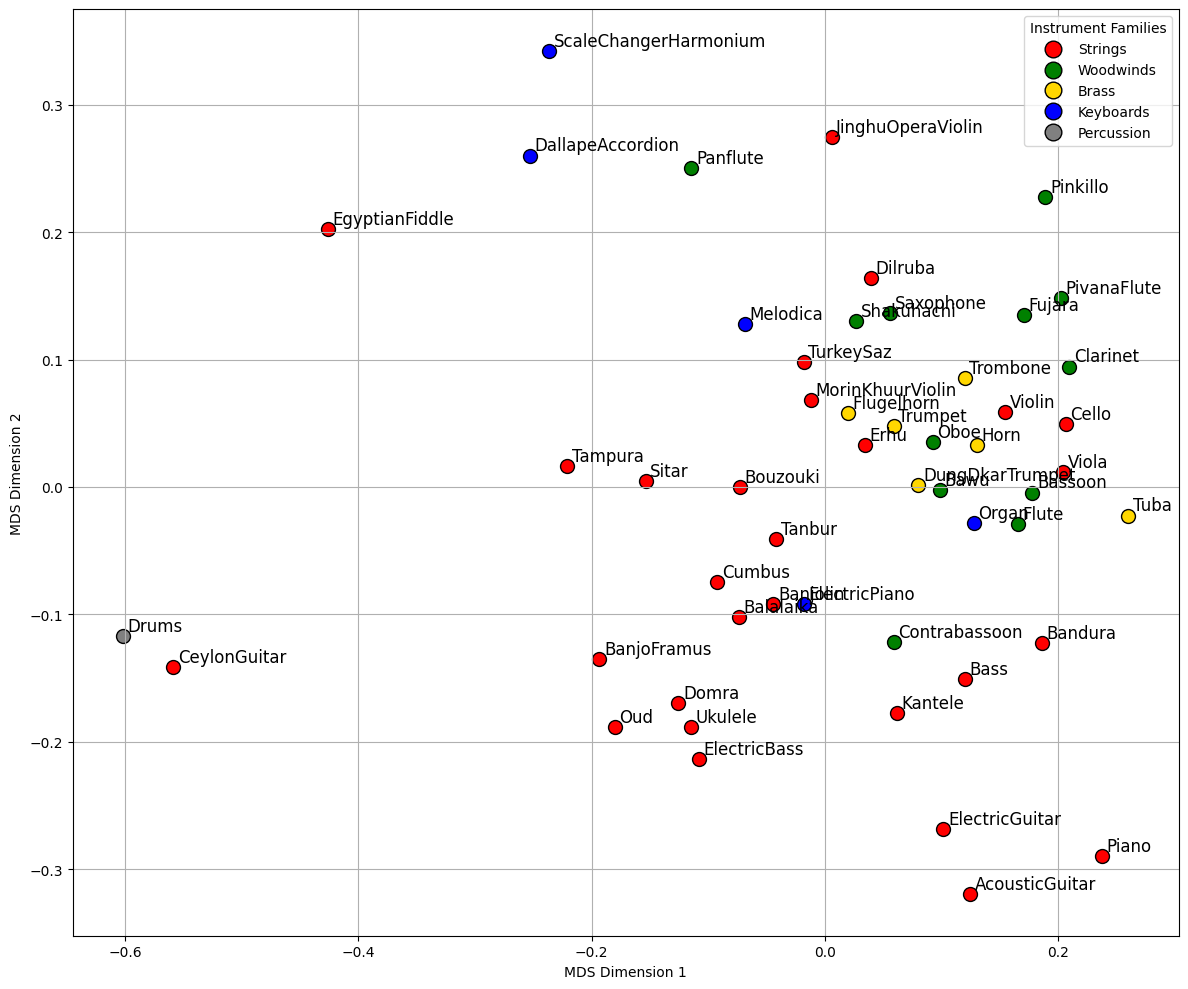

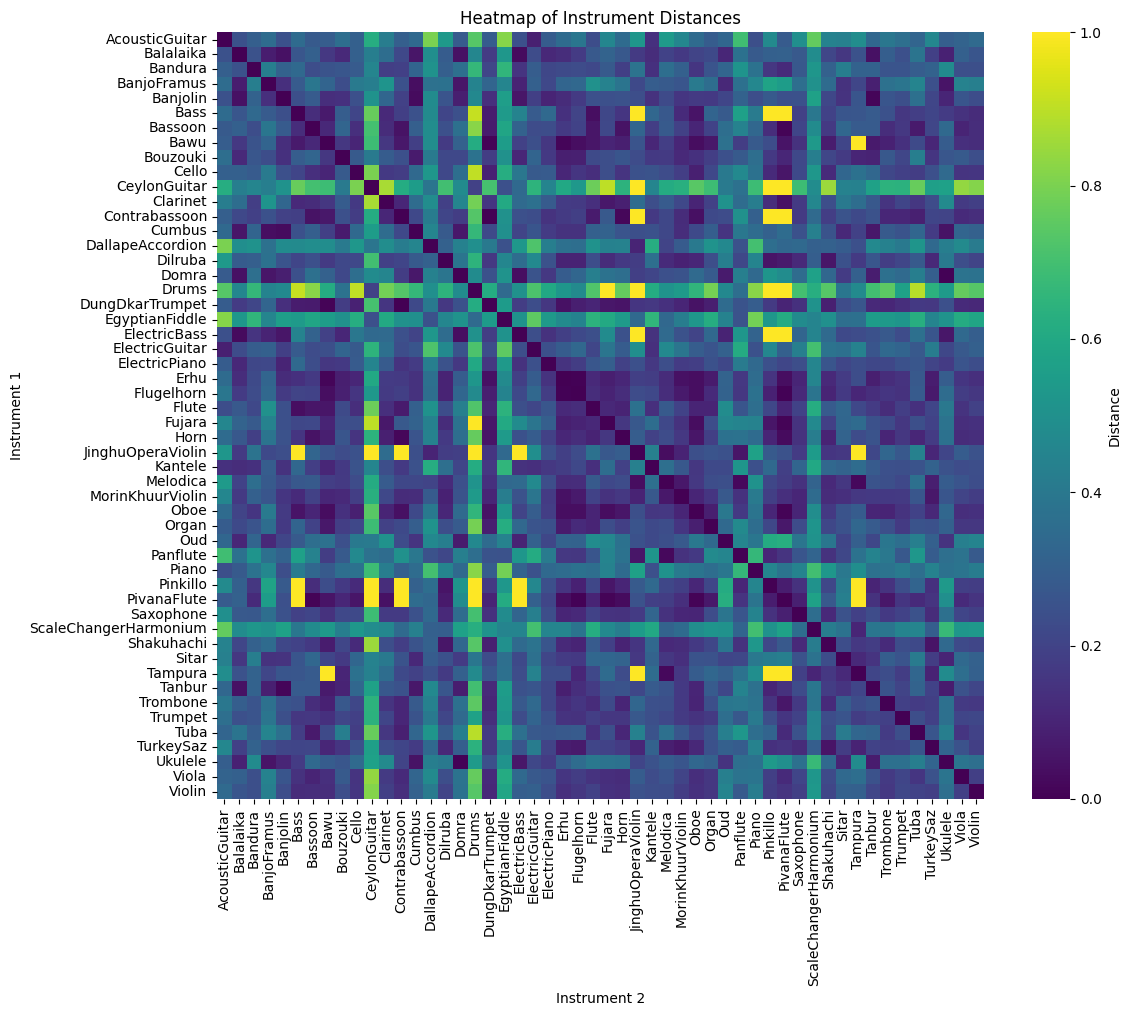

In [11]:
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(distance_matrix.values)

plt.figure(figsize=(12, 10))

for i, label in enumerate(distance_matrix.index):
    group = instrument_groups.get(label, "Others")
    color = group_colors[group]
    plt.scatter(coords[i, 0], coords[i, 1],
                color=color, edgecolor="black", s=100)
    plt.text(coords[i, 0]+0.004, coords[i, 1]+0.004,
             label, fontsize=12)

handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=col, markersize=12,
                      markeredgecolor="black")
           for col in group_colors.values()]
labels = group_colors.keys()
plt.legend(handles, labels, title="Instrument Families")

plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True)
plt.tight_layout()


save_folder = 'experiments/instrument distances'
os.makedirs(save_folder, exist_ok=True)

plot_path = os.path.join(save_folder, 'MDS_mcadams_-1.pdf')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(f"Plot saved to: {plot_path}")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(distance_matrix, cmap='viridis', square=True, cbar_kws={'label': 'Distance'})
plt.title("Heatmap of Instrument Distances")
plt.tight_layout()
plt.show()

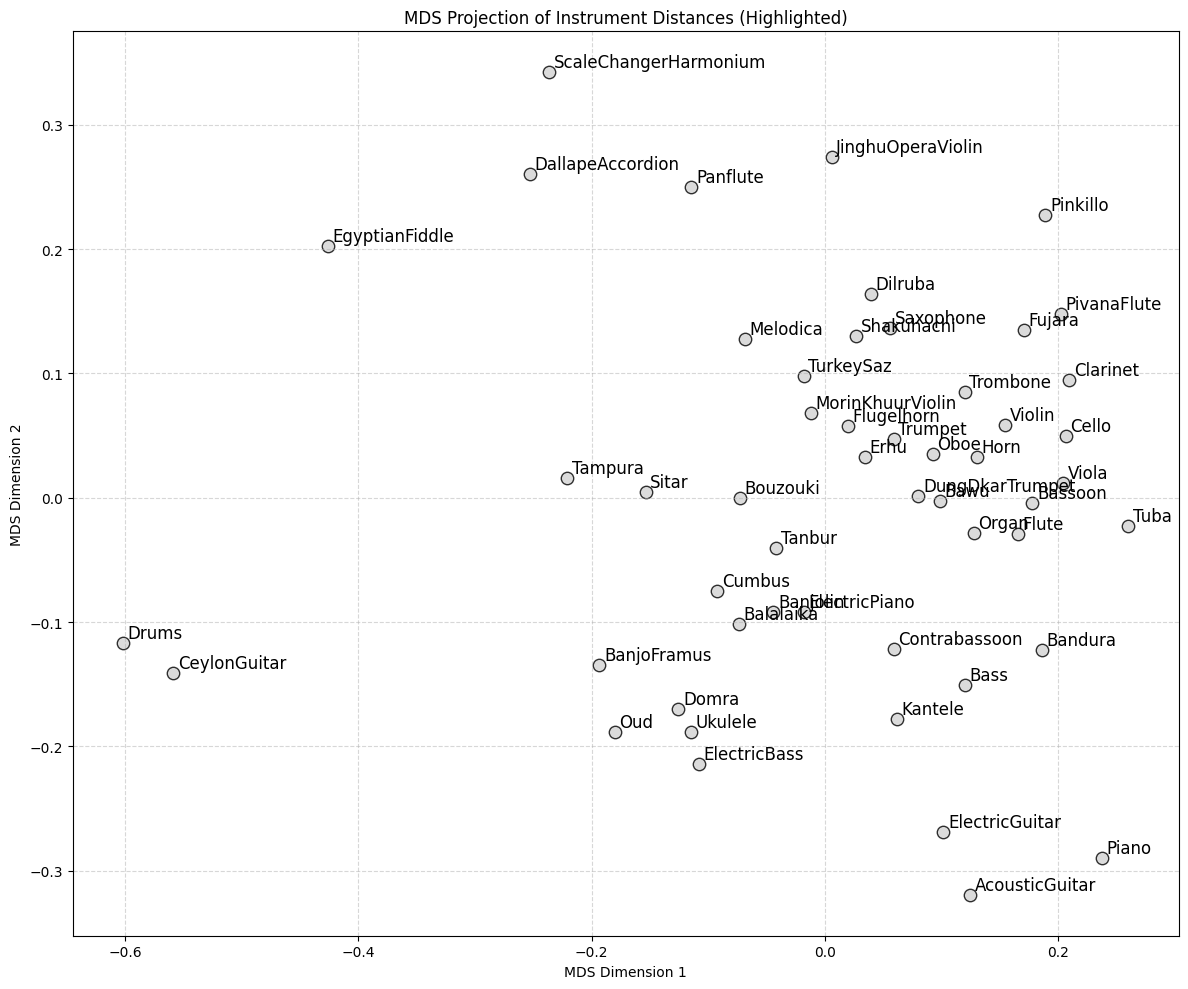

In [12]:
highlight_instruments = {}#{"Piano", "Violin", "Viola", "Drums"}

plt.figure(figsize=(12, 10))

for i, label in enumerate(distance_matrix.index):
    if label in highlight_instruments:
        plt.scatter(coords[i, 0], coords[i, 1],
                    color="red", edgecolor="black", s=120, zorder=3)
        plt.text(coords[i, 0]+0.004, coords[i, 1]+0.004,
                 label, fontsize=15, fontweight="bold", color="red")
    else:
        plt.scatter(coords[i, 0], coords[i, 1],
                    color="lightgrey", edgecolor="black", s=80, alpha=0.8)
        plt.text(coords[i, 0]+0.004, coords[i, 1]+0.004,
                 label, fontsize=12, color="black")

plt.title("MDS Projection of Instrument Distances (Highlighted)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

save_folder = 'experiments/instrument distances'
os.makedirs(save_folder, exist_ok=True)

plot_path = os.path.join(save_folder, 'Proposal_V1_MDS_mcadams_-1.png') 
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()


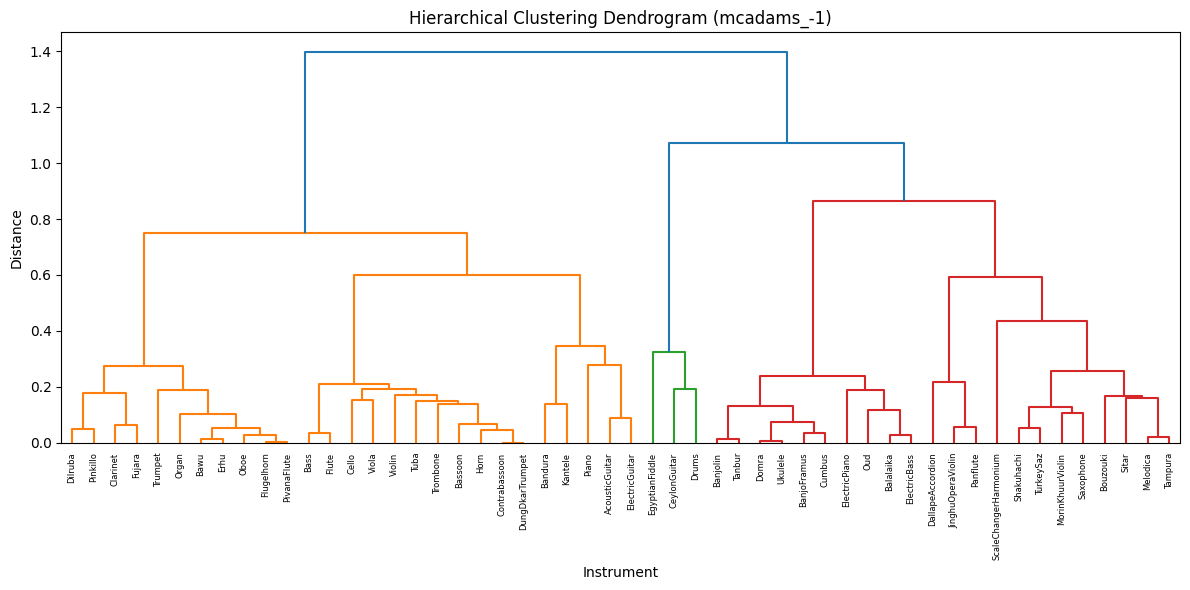

In [13]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

condensed_dist = squareform(distance_matrix.values)
linkage_matrix = linkage(condensed_dist, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=distance_matrix.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (mcadams_-1)")
plt.xlabel("Instrument")
plt.ylabel("Distance")
plt.tight_layout()

#save_folder = 'experiments/instrument distances'
#os.makedirs(save_folder, exist_ok=True)

#plot_path = os.path.join(save_folder, 'Hierarchical_Clustering_mcadams_fundamental_1000.png') 
#plt.savefig(plot_path, dpi=300, bbox_inches='tight')

#print(f"Plot saved to: {plot_path}")

plt.show()

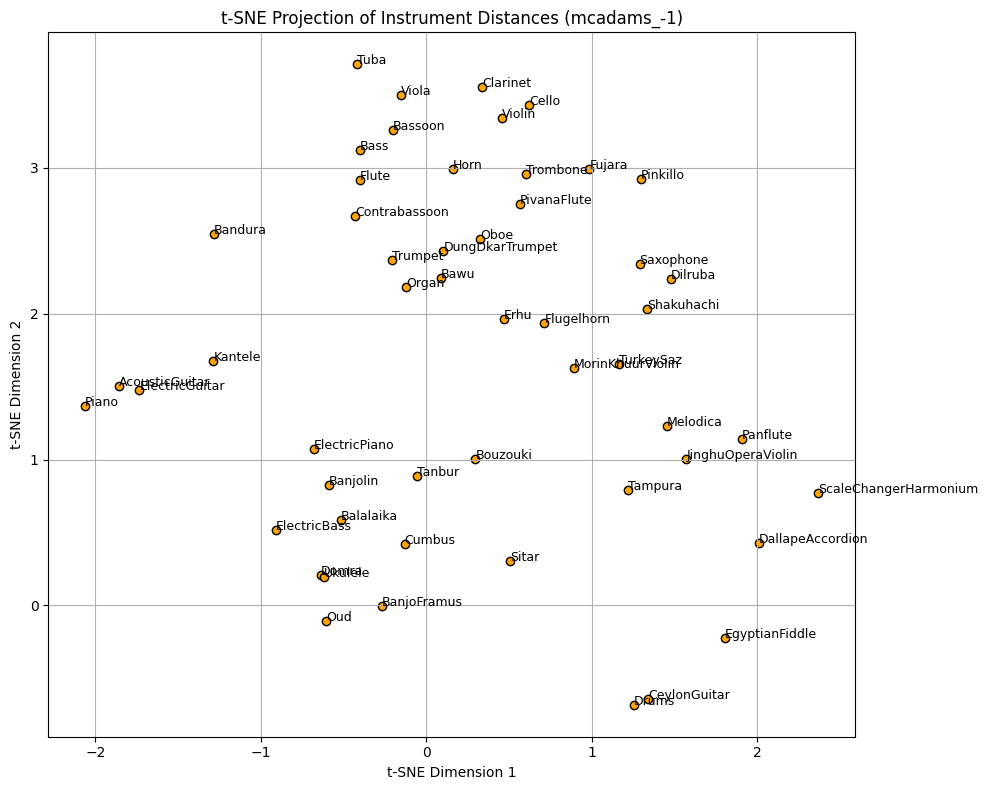

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
tsne_coords = tsne.fit_transform(distance_matrix.values)

plt.figure(figsize=(10, 8))
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], color='orange', edgecolor='black')

for i, label in enumerate(distance_matrix.index):
    plt.text(tsne_coords[i, 0], tsne_coords[i, 1], label, fontsize=9)

plt.title("t-SNE Projection of Instrument Distances (mcadams_-1)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()

#save_folder = 'experiments/instrument distances'
#os.makedirs(save_folder, exist_ok=True)

#plot_path = os.path.join(save_folder, 'tSNE_mcadams_fundamental_1000.png') 
#plt.savefig(plot_path, dpi=300, bbox_inches='tight')

#print(f"Plot saved to: {plot_path}")


plt.show()

In [15]:
import os
style_pair_distances = defaultdict(list)

for i in range(20, 109):
    filename = f"{i}.arff"
    file_path = os.path.join(base_path, filename)

    with open(file_path, 'r') as f:
        data = arff.load(f)

    df = pd.DataFrame(data['data'], columns=[attr[0] for attr in data['attributes']])

    distance_cols = [col for col in df.columns if col.startswith("Distance to instrument")]
    col_to_instrument = {col: extract_instrument_name(col) for col in distance_cols}

    # Create a style label for each row: Instrument_StyleX
    df['StyleName'] = df['Instrument'] + '_Style' + df['StyleId'].astype(int).astype(str)

    for _, row in df.iterrows():
        source_style = row['StyleName']
        for col in distance_cols:
            target_inst = col_to_instrument[col]
            target_style_num = int(col.split('style ')[-1])  # Extract style number
            target_style = f"{target_inst}_Style{target_style_num}"
            val = row[col]
            if val is not None and not pd.isna(val):
                style_pair_distances[(source_style, target_style)].append(val)


In [16]:
style_distances = {
    (s1, s2): np.mean(dists)
    for (s1, s2), dists in style_pair_distances.items()
}

all_styles = sorted(set([s for pair in style_distances.keys() for s in pair]))
style_df = pd.DataFrame(index=all_styles, columns=all_styles, dtype=float)

for (s1, s2), dist in style_distances.items():
    style_df.loc[s1, s2] = dist

# min-max-scaling
flat_values = style_df.values.flatten()
valid_values = flat_values[~np.isnan(flat_values)]  # Exclude NaNs

min_val = valid_values.min()
max_val = valid_values.max()
style_df = (style_df - min_val) / (max_val - min_val)
    
np.fill_diagonal(style_df.values, 0)
style_df.fillna(1.0, inplace=True)

In [17]:
with pd.option_context('display.max_rows', None):
    print(style_df)

                              AcousticGuitar_Style1  AcousticGuitar_Style10  \
AcousticGuitar_Style1                      0.000000                0.038187   
AcousticGuitar_Style10                     0.038187                0.000000   
AcousticGuitar_Style11                     0.044165                0.054238   
AcousticGuitar_Style12                     0.027931                0.028670   
AcousticGuitar_Style2                      0.017725                0.039605   
AcousticGuitar_Style3                      0.039229                0.068795   
AcousticGuitar_Style4                      0.048307                0.052525   
AcousticGuitar_Style5                      0.039089                0.059417   
AcousticGuitar_Style6                      0.024531                0.032159   
AcousticGuitar_Style7                      0.072867                0.089032   
AcousticGuitar_Style8                      0.054010                0.063769   
AcousticGuitar_Style9                      0.018818 

In [18]:
def filter_distance_matrix_by_instruments(distance_df: pd.DataFrame, instruments: list[str]) -> pd.DataFrame:
    """
    Returns a reduced distance matrix containing only styles belonging to the specified instruments.

    Parameters:
        distance_df (pd.DataFrame): Square distance matrix with style names like "Instrument_StyleX"
        instruments (list of str): List of instrument names (e.g., ["Violin", "Cello"])

    Returns:
        pd.DataFrame: Filtered distance matrix
    """
    # Match rows and columns that start with any instrument name followed by '_Style'
    pattern = re.compile(rf"^({'|'.join(map(re.escape, instruments))})_Style\d+(\.0)?$")
    
    # Find matching style names
    matching_styles = [label for label in distance_df.index if pattern.match(label)]
    
    # Subset the matrix
    filtered_df = distance_df.loc[matching_styles, matching_styles]

    return filtered_df

In [33]:
#instrument_list = ["Piano", "ElectricGuitar", "AcousticGuitar"]
#instrument_list = ["Violin", "Viola", "Cello"]
instrument_list = ["Violin", "Flute", "Drums"]
reduced = filter_distance_matrix_by_instruments(style_df, instrument_list)
reduced

,Drums_Style1,Drums_Style10,Drums_Style11,Drums_Style12,Drums_Style2,Drums_Style3,Drums_Style4,Drums_Style5,Drums_Style6,Drums_Style7,Drums_Style8,Drums_Style9,Flute_Style1,Flute_Style2,Flute_Style3,Flute_Style4,Flute_Style5,Flute_Style6,Flute_Style7,Flute_Style8,Violin_Style1,Violin_Style10,Violin_Style2,Violin_Style3,Violin_Style4,Violin_Style5,Violin_Style6,Violin_Style7,Violin_Style8,Violin_Style9
Drums_Style1,0.000000,0.068140,0.066048,0.081377,0.045356,0.040590,0.081367,0.107378,0.060691,0.068313,0.076044,0.090904,0.511638,0.512149,0.455733,0.479175,0.428598,0.496517,0.424089,0.462266,0.465331,0.367982,0.517359,0.589149,0.450556,0.507195,0.498011,0.549228,0.363966,0.360340
Drums_Style10,0.068140,0.000000,0.077363,0.095763,0.085617,0.068469,0.066395,0.067830,0.057132,0.045394,0.096705,0.081676,0.535420,0.535925,0.484252,0.502956,0.457180,0.537894,0.452908,0.485977,0.499871,0.402514,0.541094,0.623704,0.474229,0.530929,0.521667,0.572961,0.405137,0.400270
Drums_Style11,0.066048,0.077363,0.000000,0.065902,0.083783,0.053167,0.083934,0.095023,0.073917,0.084446,0.102692,0.072926,0.503750,0.504261,0.447845,0.471287,0.420829,0.496592,0.416200,0.477043,0.504625,0.407337,0.532135,0.628442,0.465375,0.521973,0.512800,0.564006,0.403733,0.400331
Drums_Style12,0.081377,0.095763,0.065902,0.000000,0.095359,0.069195,0.111989,0.106522,0.093996,0.103708,0.121133,0.101006,0.519715,0.520233,0.463810,0.487252,0.436819,0.500436,0.432173,0.474961,0.510857,0.413577,0.530034,0.634669,0.463290,0.519873,0.510702,0.561906,0.409950,0.406548
Drums_Style2,0.045356,0.085617,0.083783,0.095359,0.000000,0.057045,0.098519,0.132707,0.068052,0.081319,0.057918,0.109899,0.488119,0.488630,0.432214,0.455656,0.405207,0.475075,0.400569,0.438373,0.429532,0.332230,0.493455,0.553330,0.426742,0.483292,0.474186,0.525325,0.328393,0.324991
Drums_Style3,0.040590,0.068469,0.053167,0.069195,0.057045,0.000000,0.076045,0.101736,0.064618,0.071194,0.078221,0.074941,0.513006,0.513517,0.457100,0.480543,0.429979,0.502723,0.425456,0.486045,0.491338,0.392064,0.541154,0.613244,0.474351,0.530990,0.521806,0.573023,0.388400,0.384998
Drums_Style4,0.081367,0.066395,0.083934,0.111989,0.098519,0.076045,0.000000,0.088050,0.075023,0.052950,0.111030,0.066846,0.487354,0.487875,0.431456,0.454891,0.404407,0.509318,0.399827,0.521011,0.527253,0.429940,0.576063,0.651055,0.509345,0.565902,0.556799,0.615752,0.426100,0.422698
Drums_Style5,0.107378,0.067830,0.095023,0.106522,0.132707,0.101736,0.088050,0.000000,0.101254,0.084020,0.145951,0.083992,0.556322,0.561800,0.511163,0.520338,0.484030,0.541454,0.479818,0.521078,0.531646,0.434297,0.584196,0.655464,0.518655,0.566010,0.556734,0.608043,0.444616,0.439749
Drums_Style6,0.060691,0.057132,0.073917,0.093996,0.068052,0.064618,0.075023,0.101254,0.000000,0.059721,0.083150,0.085620,0.503874,0.504384,0.447967,0.471410,0.420898,0.474676,0.416323,0.420272,0.444090,0.346696,0.475369,0.567841,0.408571,0.465207,0.455983,0.507239,0.342996,0.339594
Drums_Style7,0.068313,0.045394,0.084446,0.103708,0.081319,0.071194,0.052950,0.084020,0.059721,0.000000,0.091062,0.073384,0.517068,0.517576,0.461159,0.484604,0.434060,0.536646,0.429515,0.488567,0.501931,0.404593,0.543687,0.625764,0.476842,0.533523,0.524239,0.583397,0.403014,0.398146


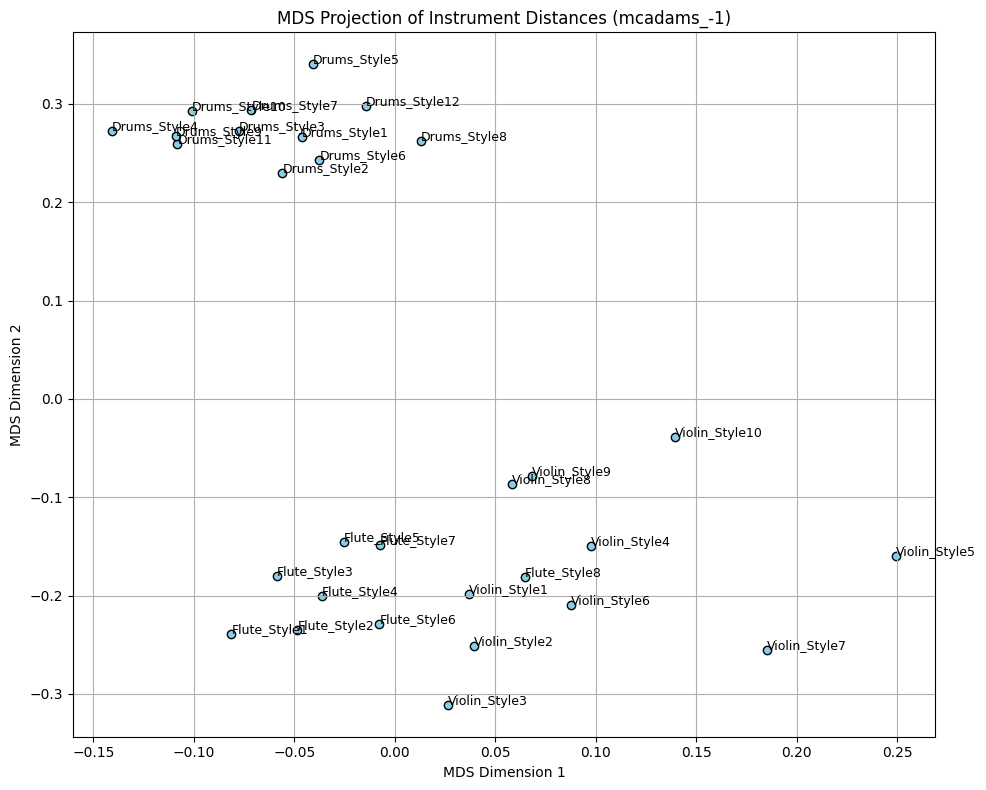

In [34]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Fit MDS on the precomputed distance matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(reduced.values)

# Plot the 2D projection
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='skyblue', edgecolor='black')

for i, label in enumerate(reduced.index):
    plt.text(coords[i, 0], coords[i, 1], label, fontsize=9)

plt.title("MDS Projection of Instrument Distances (mcadams_-1)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True)
plt.tight_layout()

#save_folder = 'experiments/instrument distances'
#os.makedirs(save_folder, exist_ok=True)

#plot_path = os.path.join(save_folder, 'MDS_mcadams_fundamental_1000.png') 
#plt.savefig(plot_path, dpi=300, bbox_inches='tight')

#print(f"Plot saved to: {plot_path}")
plt.show()

Plot saved to: experiments/instrument distances\MDS_Drums_Flute_Violin.pdf


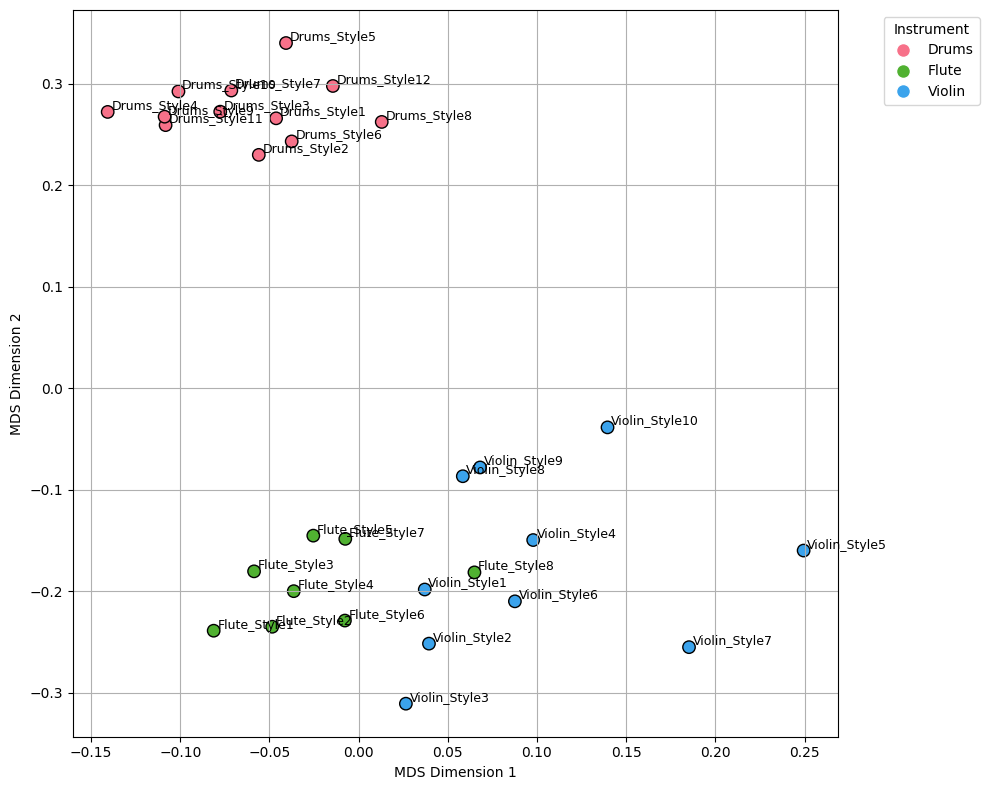

In [35]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns

# Extract instrument names (before '_Style') from index
instrument_names = reduced.index.to_series().apply(lambda x: x.split('_Style')[0])

# Assign a unique color to each instrument
unique_instruments = instrument_names.unique()
palette = sns.color_palette("husl", len(unique_instruments))  # or any other palette
instrument_to_color = {inst: color for inst, color in zip(unique_instruments, palette)}
colors = instrument_names.map(instrument_to_color)

# Fit MDS on precomputed distance matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(reduced.values)

# Plot the 2D projection
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, edgecolor='black', s=80)

# Add text labels
for i, label in enumerate(reduced.index):
    plt.text(coords[i, 0] + 0.002, coords[i, 1] + 0.002, label, fontsize=9)

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=inst,
                      markerfacecolor=instrument_to_color[inst], markersize=10)
           for inst in unique_instruments]
plt.legend(handles=handles, title="Instrument", bbox_to_anchor=(1.05, 1), loc='upper left')

#plt.title("MDS Projection of Instrument Distances (mcadams_-1)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True)
plt.tight_layout()

save_folder = 'experiments/instrument distances'
os.makedirs(save_folder, exist_ok=True)

plot_path = os.path.join(save_folder, 'MDS_Drums_Flute_Violin.pdf')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

print(f"Plot saved to: {plot_path}")

plt.show()